In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [13]:
# Make the corner plot for the MCMC results
system_name = 'B2045'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [14]:
samples

,chi2,vel_disp,x,y,ellip,pa
0,1.793545,281.4125,0.715652,1.147228,0.596266,32.09168
1,2.502467,281.4165,0.714888,1.146574,0.596239,32.01318
2,3.179100,281.4950,0.717153,1.143287,0.597012,32.05892
3,2.158707,281.4467,0.717069,1.147987,0.597252,32.03035
4,3.317281,281.4178,0.712638,1.151353,0.596902,31.97045
...,...,...,...,...,...,...
3018,4.798487,281.3714,0.716119,1.146249,0.602229,32.11216
3019,6.194975,281.3751,0.712858,1.149598,0.602339,31.97110
3020,7.248280,281.3468,0.715080,1.145503,0.601360,31.95638
3021,5.667989,281.3157,0.720769,1.143568,0.599388,31.96991


In [15]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [16]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

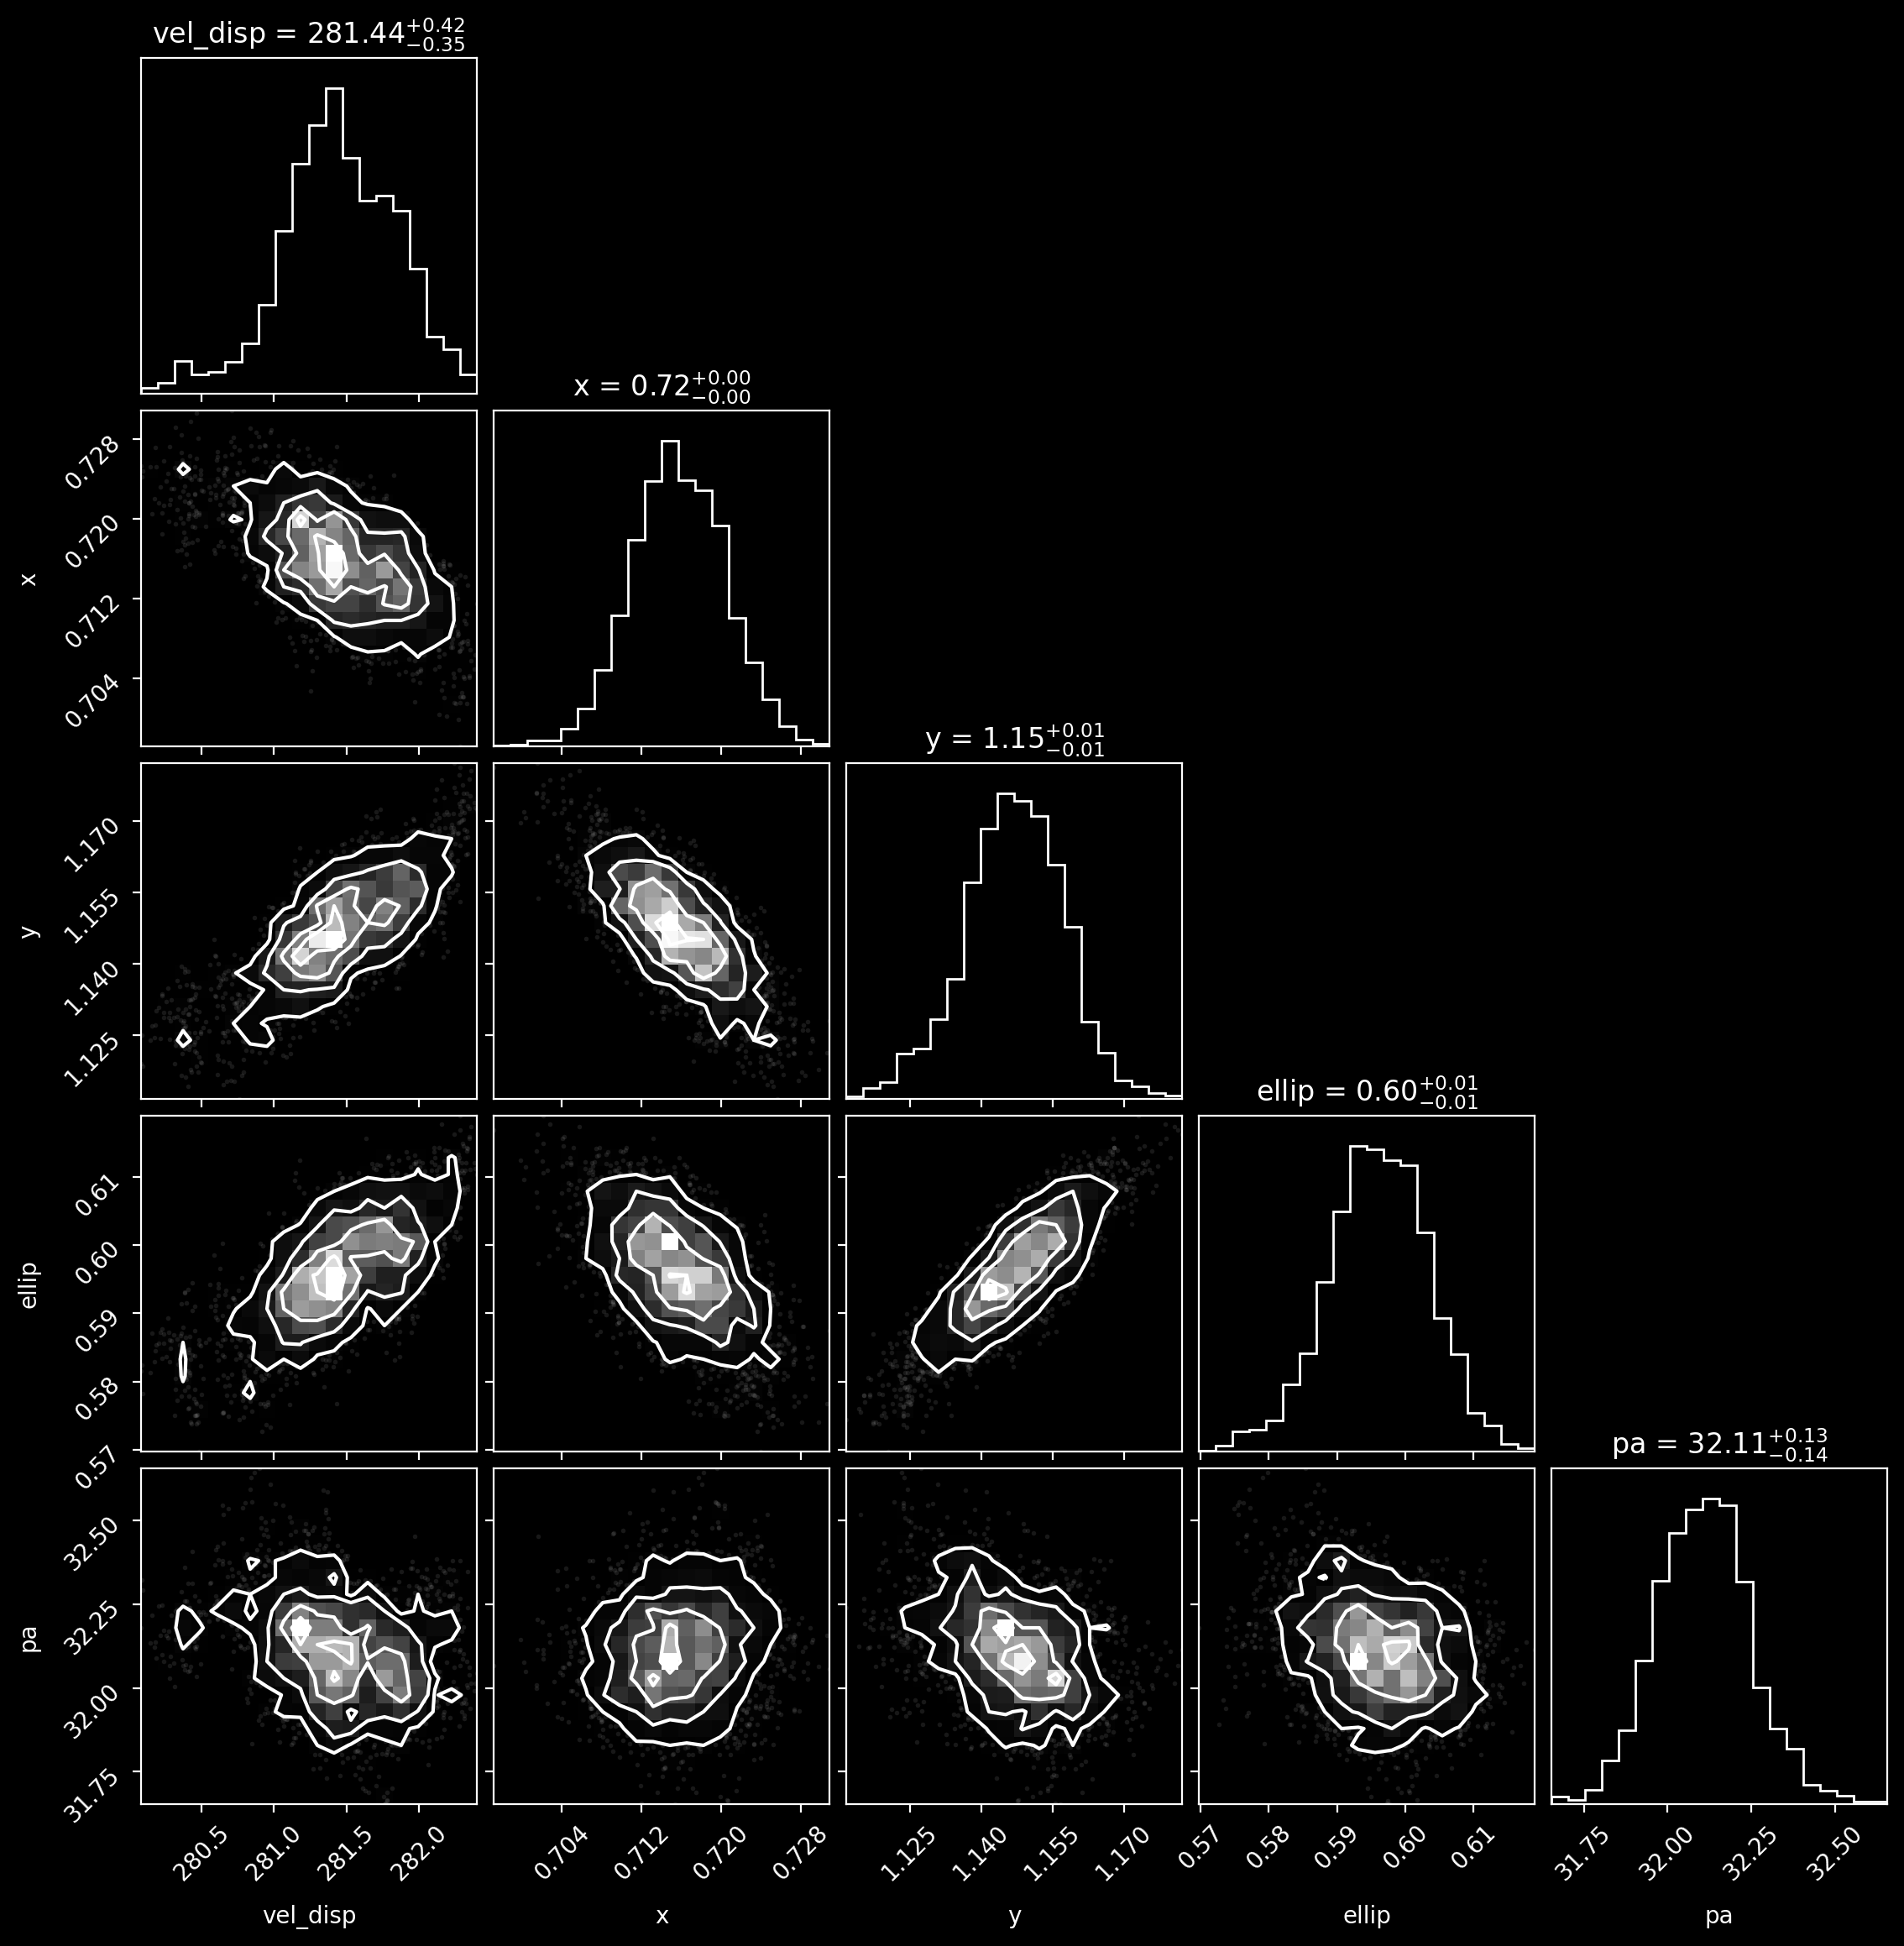

In [16]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')